In [1]:
import pandas as pd
import sqlite3


df = pd.read_csv("/content/CJA07.20251212152238.csv")

print("Raw dataset loaded. Rows:", len(df))

conn = sqlite3.connect("crime.db")   # creates file if it doesn't exist
cursor = conn.cursor()

# Write entire dataframe into SQL table
df.to_sql("crime_raw", conn, if_exists="replace", index=False)

print("Raw dataset stored successfully in database as table: crime_raw")

# Close the connection
conn.close()

Raw dataset loaded. Rows: 148896
Raw dataset stored successfully in database as table: crime_raw


Preprocessing

In [2]:
import numpy as np

df = df.rename(columns={
    "STATISTIC": "statistic_code",
    "STATISTIC Label": "statistic_label",
    "TLIST(A1)": "tlist",
    "C03037V03742": "station_code",
    "Garda Station": "garda_station",
    "C02480V03003": "offence_code",
    "Type of Offence": "offence_name",
    "UNIT": "unit",
    "VALUE": "value"
})

In [3]:
# 3. Convert code columns to integers
df["station_code"] = pd.to_numeric(df["station_code"], errors="coerce")
df["offence_code"] = pd.to_numeric(df["offence_code"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [4]:
# 4. Clean Garda station names
# Remove leading station code from name (e.g., "35301 Abbeyfeale, Limerick Division")

def clean_station(text):
    if pd.isna(text):
        return text
    text = str(text).strip()
    # Remove leading numeric code
    parts = text.split(" ", 1)
    if parts[0].isdigit() and len(parts) > 1:
        return parts[1].strip()
    return text

df["garda_station"] = df["garda_station"].apply(clean_station)

In [5]:
# 5. Extract county/division from station name
# e.g., "Abbeyfeale, Limerick Division" → "Limerick Division"
def extract_division(text):
    if pd.isna(text):
        return np.nan
    parts = text.split(",")
    if len(parts) > 1:
        return parts[-1].strip()
    return np.nan

df["division"] = df["garda_station"].apply(extract_division)

In [6]:
# 6. Standardise offence names
# Remove trailing code (e.g., "(03)")

def clean_offence_name(text):
    if pd.isna(text):
        return text
    text = str(text)
    # Remove "(03)" or similar
    text = text.rsplit("(", 1)[0].strip()
    return text

df["offence_name_clean"] = df["offence_name"].apply(clean_offence_name)

In [7]:
# 7. Remove missing or duplicate rows
df = df.dropna(subset=["Year", "garda_station", "offence_name", "value"])
df = df.drop_duplicates()

In [8]:
# 8. Preview cleaned data
(df.head())

,statistic_code,statistic_label,tlist,Year,station_code,garda_station,offence_code,offence_name,unit,value,division,offence_name_clean
0,CJA07,Recorded crime incidents,2003,2003,35301,"Abbeyfeale, Limerick Division",3,"Attempts/threats to murder, assaults, harassme...",Number,18.0,Limerick Division,"Attempts/threats to murder, assaults, harassme..."
1,CJA07,Recorded crime incidents,2003,2003,35301,"Abbeyfeale, Limerick Division",4,Dangerous or negligent acts (04),Number,14.0,Limerick Division,Dangerous or negligent acts
2,CJA07,Recorded crime incidents,2003,2003,35301,"Abbeyfeale, Limerick Division",5,Kidnapping and related offences (05),Number,0.0,Limerick Division,Kidnapping and related offences
3,CJA07,Recorded crime incidents,2003,2003,35301,"Abbeyfeale, Limerick Division",6,"Robbery, extortion and hijacking offences (06)",Number,0.0,Limerick Division,"Robbery, extortion and hijacking offences"
4,CJA07,Recorded crime incidents,2003,2003,35301,"Abbeyfeale, Limerick Division",7,Burglary and related offences (07),Number,27.0,Limerick Division,Burglary and related offences


Transformation

In [9]:
# 2. Total crimes per year
crimes_per_year = df.groupby("Year")["value"].sum().reset_index()
crimes_per_year.rename(columns={"value": "total_crimes"}, inplace=True)

print("\nTotal crimes per year:")
print(crimes_per_year.head())



Total crimes per year:
   Year  total_crimes
0  2003      228531.0
1  2004      232345.0
2  2005      252925.0
3  2006      268029.0
4  2007      283626.0


In [10]:
# 3. Total crimes per Garda Station

crimes_per_station = df.groupby("garda_station")["value"].sum().reset_index()
crimes_per_station.rename(columns={"value": "total_crimes"}, inplace=True)

print("\nTotal crimes per Garda station:")
print(crimes_per_station.head())


Total crimes per Garda station:
                      garda_station  total_crimes
0     Abbeyfeale, Limerick Division        4097.0
1  Abbeyleix, Laois/Offaly Division        3871.0
2          Adare, Limerick Division        1308.0
3        Aglish, Waterford Division         563.0
4        Ahascragh, Galway Division         588.0


In [11]:
# 4. Total crimes per Offence Type

crimes_per_offence = df.groupby("offence_name_clean")["value"].sum().reset_index()
crimes_per_offence.rename(columns={"value": "total_crimes"}, inplace=True)

print("\nTotal crimes per offence type:")
print(crimes_per_offence.head())


Total crimes per offence type:
                                  offence_name_clean  total_crimes
0  Attempts/threats to murder, assaults, harassme...      400043.0
1                      Burglary and related offences      461463.0
2                           Controlled drug offences      376592.0
3  Damage to property and to the environment  off...      665778.0
4                        Dangerous or negligent acts      239278.0


In [12]:
# 5. Crime trends for each offence type
# (Year-wise totals for each offence category)
offence_trends = df.groupby(["Year", "offence_name_clean"])["value"].sum().reset_index()

print("\nOffence trends:")
print(offence_trends.head())


Offence trends:
   Year                                 offence_name_clean    value
0  2003  Attempts/threats to murder, assaults, harassme...  13537.0
1  2003                      Burglary and related offences  25755.0
2  2003                           Controlled drug offences   9295.0
3  2003  Damage to property and to the environment  off...  34022.0
4  2003                        Dangerous or negligent acts  11962.0


In [13]:
# 6. Year-over-Year % change in total crime
crimes_per_year["yoy_change_percent"] = crimes_per_year["total_crimes"].pct_change() * 100

print("\nYear-over-year change:")
print(crimes_per_year.head())



Year-over-year change:
   Year  total_crimes  yoy_change_percent
0  2003      228531.0                 NaN
1  2004      232345.0            1.668920
2  2005      252925.0            8.857518
3  2006      268029.0            5.971731
4  2007      283626.0            5.819146


In [14]:
# 7. Total crimes per Division (County)
if "division" in df.columns:
    crimes_per_division = df.groupby("division")["value"].sum().reset_index()
    crimes_per_division.rename(columns={"value": "total_crimes"}, inplace=True)

    print("\nTotal crimes per division:")
    print(crimes_per_division.head())


Total crimes per division:
                  division  total_crimes
0  Cavan/Monaghan Division      115248.0
1           Clare Division       87881.0
2       Cork City Division      300517.0
3      Cork North Division      104025.0
4       Cork West Division       69861.0


In [15]:
# 8. Save transformed datasets
crimes_per_year.to_csv("T1_crimes_per_year.csv", index=False)
crimes_per_station.to_csv("T2_crimes_per_station.csv", index=False)
crimes_per_offence.to_csv("T3_crimes_per_offence.csv", index=False)
offence_trends.to_csv("T4_offence_trends.csv", index=False)

if "division" in df.columns:
    crimes_per_division.to_csv("T5_crimes_per_division.csv", index=False)

print("\nTransformation complete. Files saved:")
print("- T1_crimes_per_year.csv")
print("- T2_crimes_per_station.csv")
print("- T3_crimes_per_offence.csv")
print("- T4_offence_trends.csv")
if "division" in df.columns:
    print("- T5_crimes_per_division.csv")



Transformation complete. Files saved:
- T1_crimes_per_year.csv
- T2_crimes_per_station.csv
- T3_crimes_per_offence.csv
- T4_offence_trends.csv
- T5_crimes_per_division.csv


Analysis

In [16]:
# Load transformed datasets
crimes_per_year = pd.read_csv("T1_crimes_per_year.csv")
crimes_per_station = pd.read_csv("T2_crimes_per_station.csv")
crimes_per_offence = pd.read_csv("T3_crimes_per_offence.csv")
offence_trends = pd.read_csv("T4_offence_trends.csv")

# 1. Highest crime year
highest_year = crimes_per_year.loc[crimes_per_year["total_crimes"].idxmax()]

print("Highest Crime Year:")
print(highest_year)
print()


Highest Crime Year:
Year                    2008.000000
total_crimes          296162.000000
yoy_change_percent         4.419905
Name: 5, dtype: float64



In [17]:
# 2. Lowest crime year
lowest_year = crimes_per_year.loc[crimes_per_year["total_crimes"].idxmin()]

print("Lowest Crime Year:")
print(lowest_year)
print()


Lowest Crime Year:
Year                    2020.000000
total_crimes          185773.000000
yoy_change_percent       -16.436662
Name: 17, dtype: float64



In [18]:

# 3. Year with the highest YoY increase
if "yoy_change_percent" in crimes_per_year.columns:
    yoy_max = crimes_per_year.loc[crimes_per_year["yoy_change_percent"].idxmax()]
    print("Highest Year-over-Year Increase:")
    print(yoy_max)
    print()

Highest Year-over-Year Increase:
Year                    2022.000000
total_crimes          210036.000000
yoy_change_percent        13.048393
Name: 19, dtype: float64



In [19]:

# 4. Top 10 Garda stations by total crime
top_stations = crimes_per_station.sort_values("total_crimes", ascending=False).head(10)

print("Top 10 Garda Stations by Crime:")
print(top_stations)
print()


Top 10 Garda Stations by Crime:
                                       garda_station  total_crimes
456     Pearse Street, D.M.R. South Central Division      213708.0
517      Store Street, D.M.R. North Central Division      201175.0
122  Bridewell Dublin, D.M.R. North Central Division      136214.0
527               Tallaght, D.M.R. Southern Division      125924.0
109          Blanchardstown, D.M.R. Western Division      121672.0
278                        Gaillimh, Galway Division       99605.0
555                    Waterford, Waterford Division       97706.0
304                  Henry Street, Limerick Division       93271.0
16               Anglesea Street, Cork City Division       76482.0
319      Kevin Street, D.M.R. South Central Division       71335.0



In [20]:
# 5. Crime category with highest incidents
top_offence = crimes_per_offence.loc[crimes_per_offence["total_crimes"].idxmax()]

print("Most Common Offence Type:")
print(top_offence)
print()

Most Common Offence Type:
offence_name_clean    Theft and related offences
total_crimes                           1566418.0
Name: 10, dtype: object



In [21]:

# 6. Crime trending upwards (offence types increasing over time)
increasing_trends = (
    offence_trends.groupby("offence_name_clean")["value"].sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Offence Types with Increasing Long-term Trends:")
print(increasing_trends)
print()

Offence Types with Increasing Long-term Trends:
offence_name_clean
Theft and related offences                                                1566418.0
Public order and other social code offences                                907802.0
Damage to property and to the environment  offences                        665778.0
Burglary and related offences                                              461463.0
Attempts/threats to murder, assaults, harassments and related offences     400043.0
Name: value, dtype: float64



Visualization

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Load transformed datasets
crimes_per_year = pd.read_csv("T1_crimes_per_year.csv")
crimes_per_station = pd.read_csv("T2_crimes_per_station.csv")
crimes_per_offence = pd.read_csv("T3_crimes_per_offence.csv")
offence_trends = pd.read_csv("T4_offence_trends.csv")


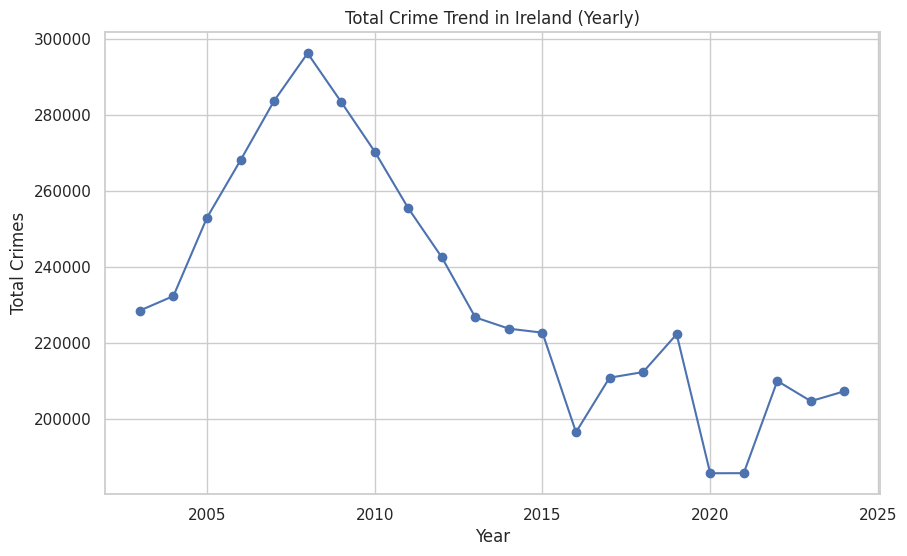

In [23]:
# 1. Line Chart – Crime Trend Over Years
plt.figure(figsize=(10, 6))
plt.plot(crimes_per_year["Year"], crimes_per_year["total_crimes"], marker="o")
plt.title("Total Crime Trend in Ireland (Yearly)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.grid(True)
plt.show()

/tmp/ipython-input-3019486352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


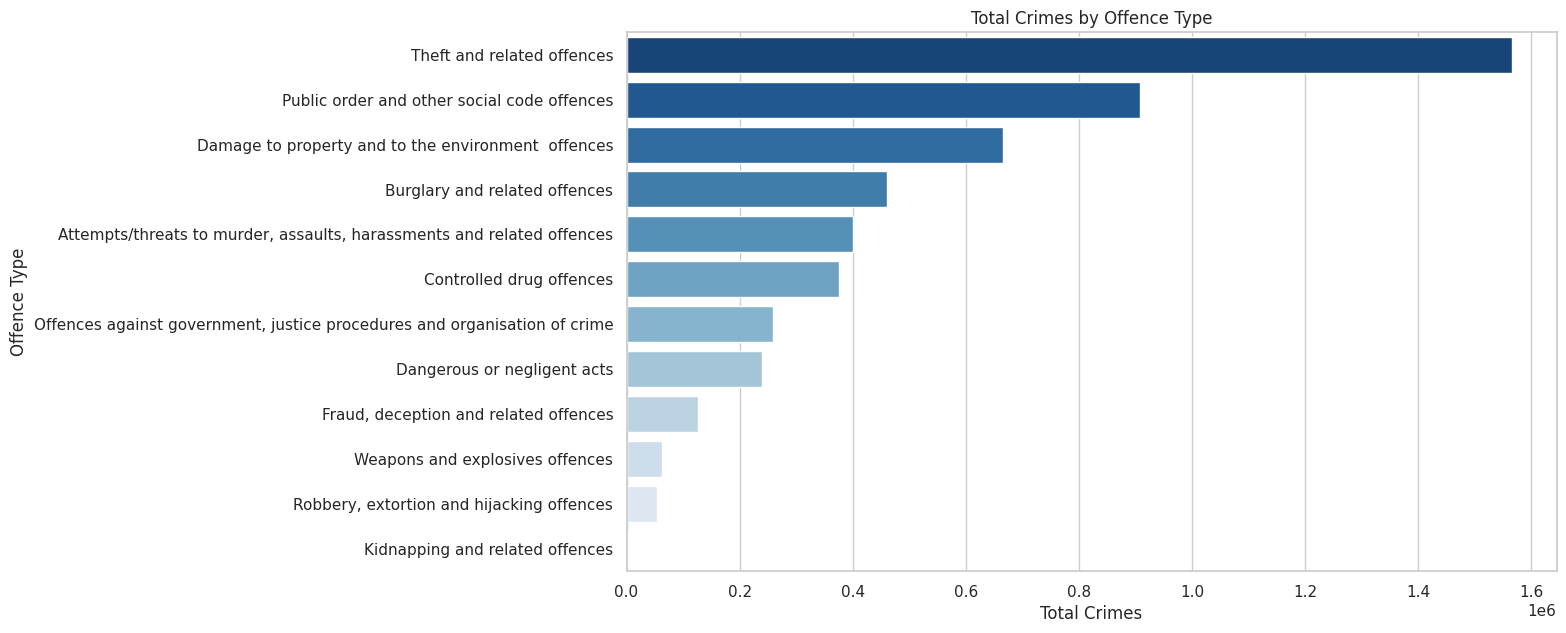

In [24]:
# 2. Bar Chart – Total Crime by Offence Type

plt.figure(figsize=(12, 7))
sns.barplot(
    data=crimes_per_offence.sort_values("total_crimes", ascending=False),
    x="total_crimes",
    y="offence_name_clean",
    palette="Blues_r"
)
plt.title("Total Crimes by Offence Type")
plt.xlabel("Total Crimes")
plt.ylabel("Offence Type")
plt.show()

/tmp/ipython-input-4024864637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


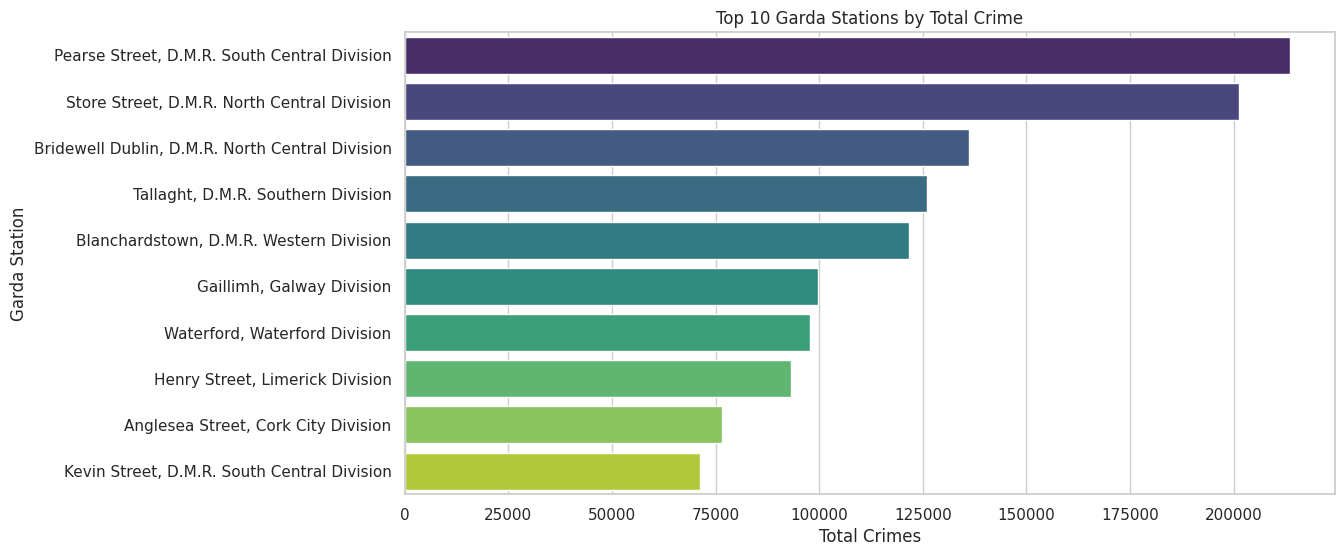

In [25]:

# 3. Top 10 Garda Stations – Horizontal Bar Chart
top10_stations = crimes_per_station.sort_values("total_crimes", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_stations,
    x="total_crimes",
    y="garda_station",
    palette="viridis"
)
plt.title("Top 10 Garda Stations by Total Crime")
plt.xlabel("Total Crimes")
plt.ylabel("Garda Station")
plt.show()

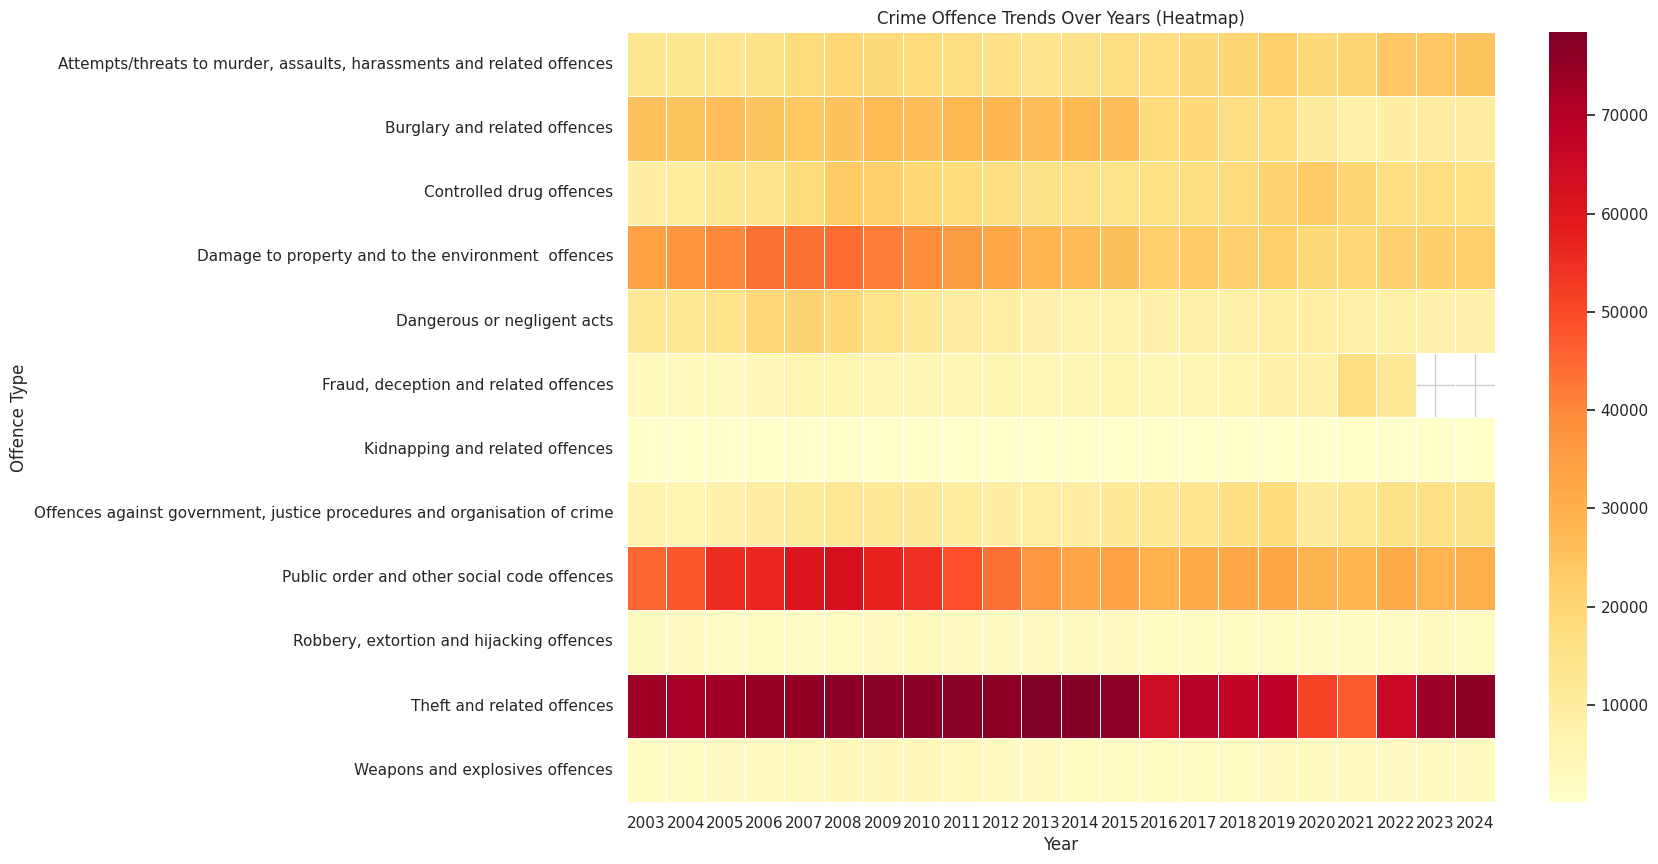

In [26]:
# 4. Heatmap – Offence Type Trends Over Years
pivot = offence_trends.pivot_table(
    index="offence_name_clean",
    columns="Year",
    values="value",
    aggfunc="sum"
)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=.5)
plt.title("Crime Offence Trends Over Years (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Offence Type")
plt.show()

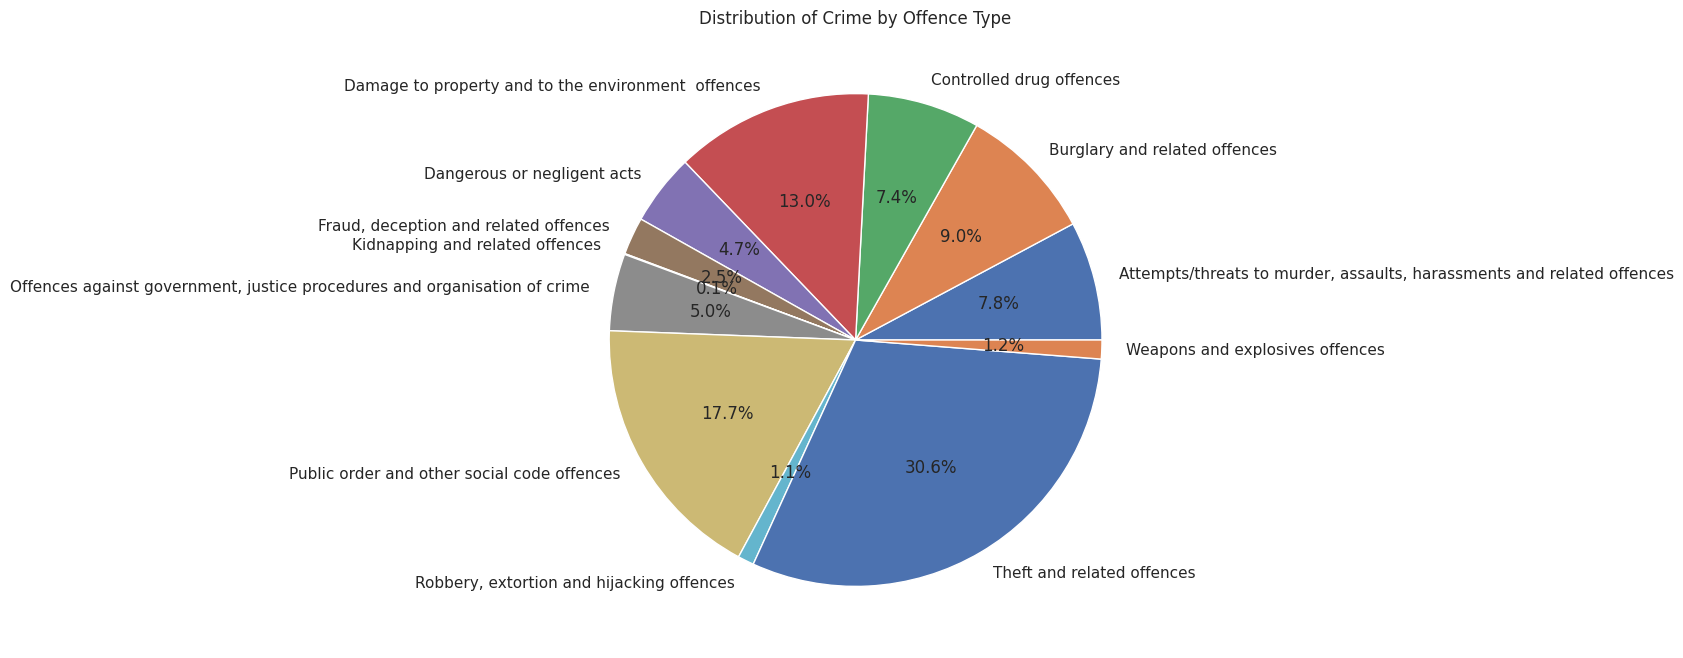

In [27]:
# 5. Pie Chart – Composition of Crime Categories
plt.figure(figsize=(8, 8))
plt.pie(
    crimes_per_offence["total_crimes"],
    labels=crimes_per_offence["offence_name_clean"],
    autopct="%1.1f%%"
)
plt.title("Distribution of Crime by Offence Type")
plt.show()